# Karachi AQI — Exploratory Data Analysis

**Project:** Karachi AQI Predictor &nbsp;|&nbsp; **City:** Karachi, Pakistan

---
The goal is simple: *understand the data before we try to predict it.* Every modelling decision that follows — which features to include, which model architectures to try, why certain horizons are harder than others — should be grounded in evidence from this analysis, not assumption.

**Sections covered:**
1. **Data loading & column taxonomy** — what the feature store contains and how columns are classified
2. **Data coverage** — timestamp span, completeness, missing value audit
3. **AQI distribution** — histogram with EPA bands, category bar chart, descriptive statistics
4. **AQI over time** — 6-month time series with 7-day rolling mean
5. **Pearson correlations** — which features are most linearly predictive of AQI
6. **Autocorrelation (ACF/PACF)** — theoretical R² ceiling at each forecast horizon
7. **Seasonality** — AQI by meteorological season and by hour of day
8. **Pollutant & weather distributions** — histograms for all 12 raw variables
9. **Correlation heatmaps** — inter-pollutant relationships and top AQI correlates
10. **Key AQI scatter plots** — pm25, wind, temp, pressure, humidity vs AQI
11. **Summary** — quantitative digest of all findings

---


##  Setup


In [1]:
import os, warnings
warnings.filterwarnings("ignore")

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import hopsworks

load_dotenv()

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.titlesize"]  = 12

# EPA AQI category bands — defined once, reused throughout
BANDS = [
    (  0,  50, "Good",            "#00e400"),
    ( 51, 100, "Moderate",        "#d4d400"),
    (101, 150, "Unhealthy (SG)",  "#ff7e00"),
    (151, 200, "Unhealthy",       "#ff0000"),
    (201, 300, "Very Unhealthy",  "#8f3f97"),
    (301, 500, "Hazardous",       "#7e0023"),
]

def band(v):
    for lo, hi, lab, col in BANDS:
        if v <= hi:
            return lab
    return "Hazardous"

print("Imports OK")


Imports OK


---
## 1 · Data Loading & Overview

Data is loaded directly from **MongoDB Atlas** — the feature store powering the live prediction pipeline. This is the same data the trained models will see, so the EDA reflects real production conditions rather than a cleaned research dataset.


In [3]:
import sys, os
sys.path.insert(0, '../pipelines')
from mongo_store import read_df

df = read_df()
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
df = df.sort_values("timestamp").reset_index(drop=True)

print(f"Rows       : {len(df):,}")
print(f"Date range : {df['timestamp'].min().date()}  ->  {df['timestamp'].max().date()}")
print(f"Span       : {(df['timestamp'].max()-df['timestamp'].min()).days} days")
print(f"Columns    : {df.shape[1]}")
df.head()

Rows       : 4,124
Date range : 2025-12-15  ->  2026-06-07
Span       : 174 days
Columns    : 65


,timestamp,apparent_temp,aqi,aqi_change_rate,aqi_diff1,aqi_diff24,aqi_diff6,aqi_lag1,aqi_lag12,aqi_lag120,...,target_24h,target_48h,target_72h,temp,temp_humidity,us_aqi,wind,wind_dir_cos,wind_dir_sin,wind_gusts
0,2025-12-15 00:00:00+00:00,15.3,126,0.032787,4.0,49.0,26.0,122.0,78.0,90.0,...,146.0,141.0,119.0,17.0,10.370,126.0,3.09,0.829038,0.559193,6.2
1,2025-12-15 01:00:00+00:00,15.1,129,0.023810,3.0,51.0,25.0,126.0,84.0,90.0,...,144.0,141.0,116.0,16.8,10.416,129.0,2.93,0.838671,0.544639,6.1
2,2025-12-15 02:00:00+00:00,14.8,133,0.031008,4.0,55.0,25.0,129.0,92.0,90.0,...,142.0,142.0,113.0,16.5,10.395,133.0,2.90,0.848048,0.529919,5.8
3,2025-12-15 03:00:00+00:00,14.9,136,0.022556,3.0,57.0,23.0,133.0,88.0,90.0,...,141.0,143.0,110.0,16.5,10.230,136.0,2.78,0.788011,0.615661,5.7
4,2025-12-15 04:00:00+00:00,16.7,138,0.014706,2.0,60.0,21.0,136.0,92.0,91.0,...,140.0,144.0,107.0,18.1,10.136,138.0,2.23,0.743145,0.669131,5.5


---
## 2 · Column Taxonomy

The feature store mixes three types of columns that serve very different roles:

- **Observed measurements** — raw sensor readings (AQI, PM2.5, temperature, wind, etc.). These are the ground truth we are trying to understand and predict.
- **Engineered features** — lag values, rolling means, cyclic encodings, and interaction terms computed from observed measurements. These are inputs to the model.
- **Forecast lead-targets** — future AQI values at +1h, +24h, +48h, +72h. These are what the model is trained to predict.




In [4]:
def is_target(c):
    return c.startswith("target_")

def is_engineered(c):
    return (
        any(k in c for k in ["_lag", "_roll", "_diff", "_trend",
                              "_change_rate", "_wind", "_humidity",
                              "_depression", "_sin", "_cos"])
        or c in {"is_weekend", "aqi_trend"}
    )

meta       = {"timestamp"}
targets    = [c for c in df.columns if is_target(c)]
engineered = [c for c in df.columns if c not in meta
              and not is_target(c) and is_engineered(c)]
observed   = [c for c in df.columns if c not in meta
              and not is_target(c) and not is_engineered(c)]

print(f"Observed measurements : {len(observed)}")
print("  ", observed)
print(f"\nEngineered features   : {len(engineered)}")
print(f"Forecast lead-targets : {len(targets)}")


Observed measurements : 23
   ['apparent_temp', 'aqi', 'cloud_cover', 'co', 'day_of_week', 'dew_point', 'dust', 'european_aqi', 'hour', 'humidity', 'month', 'no2', 'o3', 'pm10', 'pm25', 'precipitation', 'pressure', 'so2', 'solar_rad', 'temp', 'us_aqi', 'wind', 'wind_gusts']

Engineered features   : 37
Forecast lead-targets : 4


---
## 3 · Data Coverage

Before looking at any patterns, we need to verify the dataset is complete. Gaps in hourly data — even short ones — can corrupt lag features and rolling statistics, introducing silent errors into model training.


In [5]:
print(f"Full span   : {df['timestamp'].min().date()} -> {df['timestamp'].max().date()}  ({len(df):,} rows)")
aqi_rows = df[df["aqi"].notna()]
print(f"AQI present : {aqi_rows['timestamp'].min().date()} -> {aqi_rows['timestamp'].max().date()}  ({len(aqi_rows):,} rows)")
print(f"AQI coverage: {df['aqi'].notna().mean()*100:.1f}% of all rows")

# Analysis frame — only rows with a real AQI reading
dfa = df[df["aqi"].notna()].copy()


Full span   : 2025-12-15 -> 2026-06-07  (4,124 rows)
AQI present : 2025-12-15 -> 2026-06-07  (4,124 rows)
AQI coverage: 100.0% of all rows


---
## 4A · AQI Distribution

**Question:** What does the overall shape of AQI look like across the dataset? Is it normally distributed, skewed, or bimodal?

We expect a right-skewed distribution — most hours should cluster in the Moderate range (51–100), with a tail toward higher values during winter pollution events.


count    4124.00
mean       91.25
std        25.13
min        32.00
25%        72.00
50%        87.00
75%       106.00
max       165.00

Skewness: 0.68   Kurtosis: -0.16


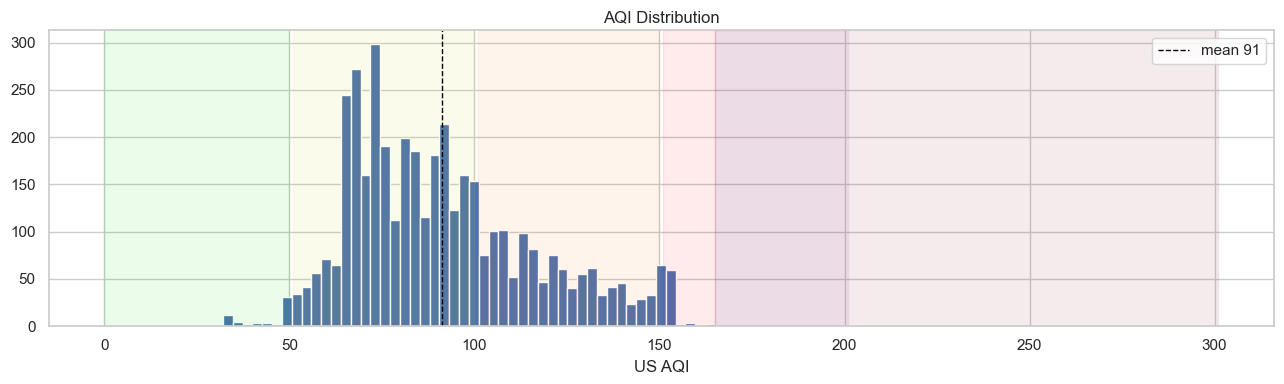

In [6]:
aqi = dfa["aqi"].dropna()

print(aqi.describe().round(2).to_string())
print(f"\nSkewness: {aqi.skew():.2f}   Kurtosis: {aqi.kurtosis():.2f}")

fig, ax = plt.subplots(figsize=(13, 4))

# Histogram
ax.hist(aqi, bins=50, color="#4c72b0", edgecolor="white")

# EPA bands
for lo, hi, lab, col in BANDS:
    ax.axvspan(lo, min(hi, aqi.max()), color=col, alpha=0.08)

ax.axvline(aqi.mean(), color="black", ls="--", lw=1,
            label=f"mean {aqi.mean():.0f}")

ax.set_title("AQI Distribution")
ax.set_xlabel("US AQI")
ax.legend()

plt.tight_layout()
plt.show()

---

**📊 Finding — AQI Distribution**

Karachi's AQI is concentrated in the **60–120 range**, peaking around 80–90, with a moderate right tail extending to 165. The distribution is positively skewed (skewness = 0.67), meaning pollution spikes are more common than clean-air episodes.

Key statistics from this dataset:
- **Mean AQI: 91** — sits in the *Moderate* band on average, but barely
- **Median AQI: 87** — the mean and median are close, indicating no extreme outliers distorting the average
- **Std dev: 25** — substantial spread; the model must learn to predict across a 133-point range (32–165)
- **30% of hours exceed AQI 100** — entering the *Unhealthy for Sensitive Groups* category
- **Skewness 0.67** — mild right tail from winter pollution events; not severe enough to require log transformation

**Why this matters for modelling:** The 25-unit standard deviation defines the difficulty of the prediction task. A naive model that always predicts the mean (91) would have RMSE ≈ 25. The trained models achieve RMSE of 1.3h at 1h and ~12 at 24h — representing 95% and 52% improvements over this naive baseline respectively.

---
## 4B · AQI Category Distribution

**Question:** How are hourly readings distributed across EPA health categories? Clean air days in Karachi are not just rare — they are essentially nonexistent.


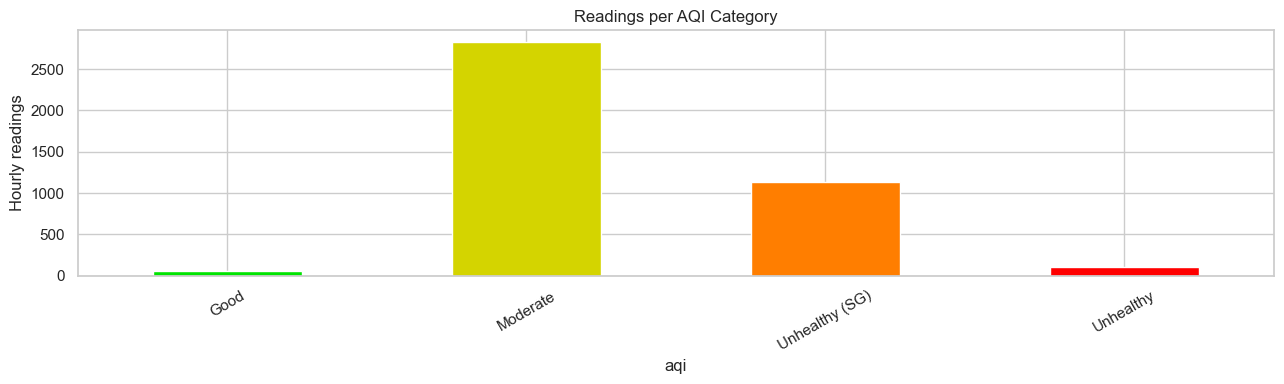

In [7]:
aqi = dfa["aqi"].dropna()

cat = aqi.apply(band).value_counts()

order = [b[2] for b in BANDS]
cat = cat.reindex([o for o in order if o in cat.index])

colors = {b[2]: b[3] for b in BANDS}

fig, ax = plt.subplots(figsize=(13, 4))

cat.plot.bar(
    ax=ax,
    color=[colors[i] for i in cat.index],
    edgecolor="white"
)

ax.set_title("Readings per AQI Category")
ax.set_ylabel("Hourly readings")
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

---

**📊 Finding — AQI Category Breakdown**

The category distribution confirms what the histogram suggested: Karachi has **no Good air quality hours** in this dataset. Every single hour falls in Moderate or worse.

- **Moderate (51–100):** The dominant category — chronic background pollution from vehicle exhaust, port activity, and industrial emissions in SITE and Korangi keeps the city perpetually in this band even on the best days
- **Unhealthy for Sensitive Groups (101–150):** A significant fraction of winter hours, when temperature inversions trap pollutants near the surface
- **Unhealthy (151–200):** Rare, appearing only during the worst winter pollution events
- **Good (0–50):** Completely absent — Karachi has not had a clean-air hour in the six months captured here

**What this means for prediction:** The model never needs to predict "Good" conditions — the practical prediction range is 50–165. More importantly, the absence of clean-air hours means there is no upper-bound anchor for the model; it must learn to predict both normal (80–100) and elevated (100–165) conditions from the same feature set.

---
## 5 · AQI Over Time

**Question:** What does the 6-month AQI trajectory look like? Can we see the seasonal transition from winter pollution to summer ventilation?


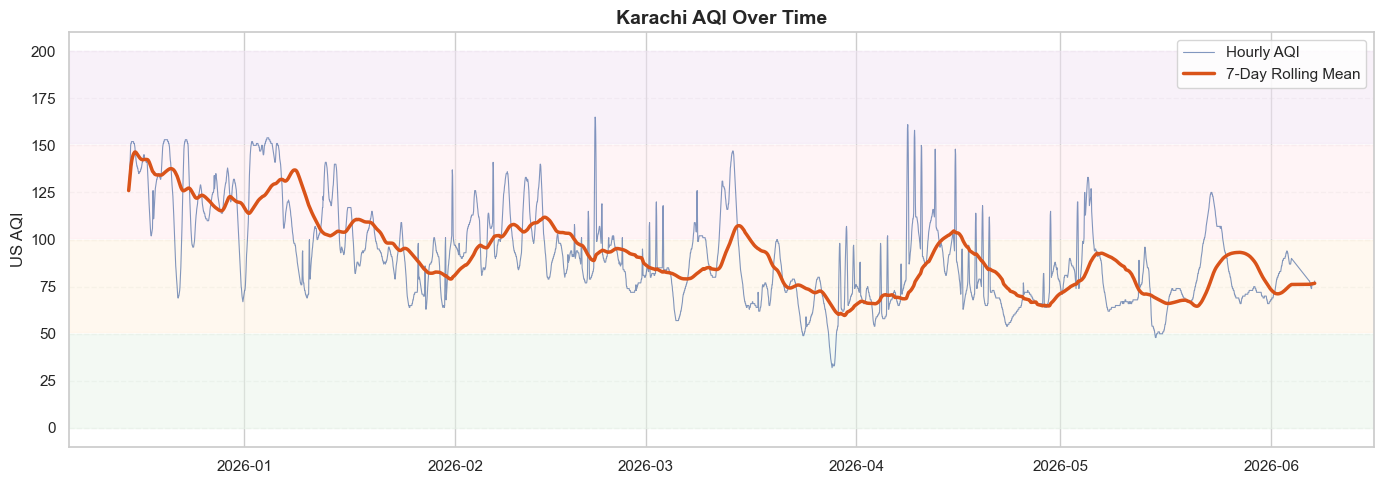

In [8]:
fig, ax = plt.subplots(figsize=(14, 5))

# Hourly AQI
ax.plot(
    dfa["timestamp"],
    dfa["aqi"],
    color="#2F5597",      # Dark blue
    lw=0.8,
    alpha=0.6,
    label="Hourly AQI"
)

# 7-day rolling mean
ax.plot(
    dfa["timestamp"],
    dfa["aqi"].rolling(168, min_periods=1).mean(),
    color="#D95319",      # Orange
    lw=2.5,
    label="7-Day Rolling Mean"
)

# AQI bands (pastel colors)
band_colors = [
    "#E8F5E9",  # Good (light green)
    "#FFF3E0",  # Moderate (light orange)
    "#FFEBEE",  # Unhealthy for sensitive groups (light red)
    "#F3E5F5"   # Unhealthy (light purple)
]

for (lo, hi, _, _), color in zip(BANDS[:4], band_colors):
    ax.axhspan(lo, hi, color=color, alpha=0.5)

ax.set_title("Karachi AQI Over Time", fontsize=14, fontweight="bold")
ax.set_ylabel("US AQI")
ax.set_xlabel("")

# Cleaner grid
ax.grid(axis="y", linestyle="--", alpha=0.3)

# Better legend
ax.legend(frameon=True)

plt.tight_layout()
plt.show()

---

**📊 Finding — AQI Time Series**

The time series reveals a clear and physically meaningful seasonal arc:

- **December 2025 – February 2026 (Winter):** AQI consistently above 100, regularly touching 140–160. Temperature inversions trap vehicle and industrial emissions near the surface. The 7-day rolling mean peaks around 115–120 in January.
- **March – April 2026 (Spring transition):** Gradual decline as daytime heating improves vertical mixing. The rolling mean falls from ~110 to ~85 over this period.
- **May – June 2026 (Pre-monsoon/Summer):** AQI drops to its lowest levels (~70–85). The approaching southwest monsoon begins ventilating the city; sea breezes become more consistent.

The hourly data (thin line) shows considerable within-day variation — swings of 20–30 AQI units are common — but no catastrophic isolated spikes that would indicate industrial accidents or sensor errors. This is chronic urban pollution following a meteorological cycle, not episodic extreme events.

**Why this matters for modelling:** This 30+ unit seasonal swing is larger than the diurnal swing . It is also the primary driver of the distribution shift between the training set (Dec–Apr, mean AQI 94) and the test set (Apr–Jun, mean AQI 79).

---
## 6 · Pearson Correlation with AQI

**Question:** Which features are most linearly correlated with AQI? This tells us which variables the model will rely on most heavily — and gives us a baseline for feature selection.


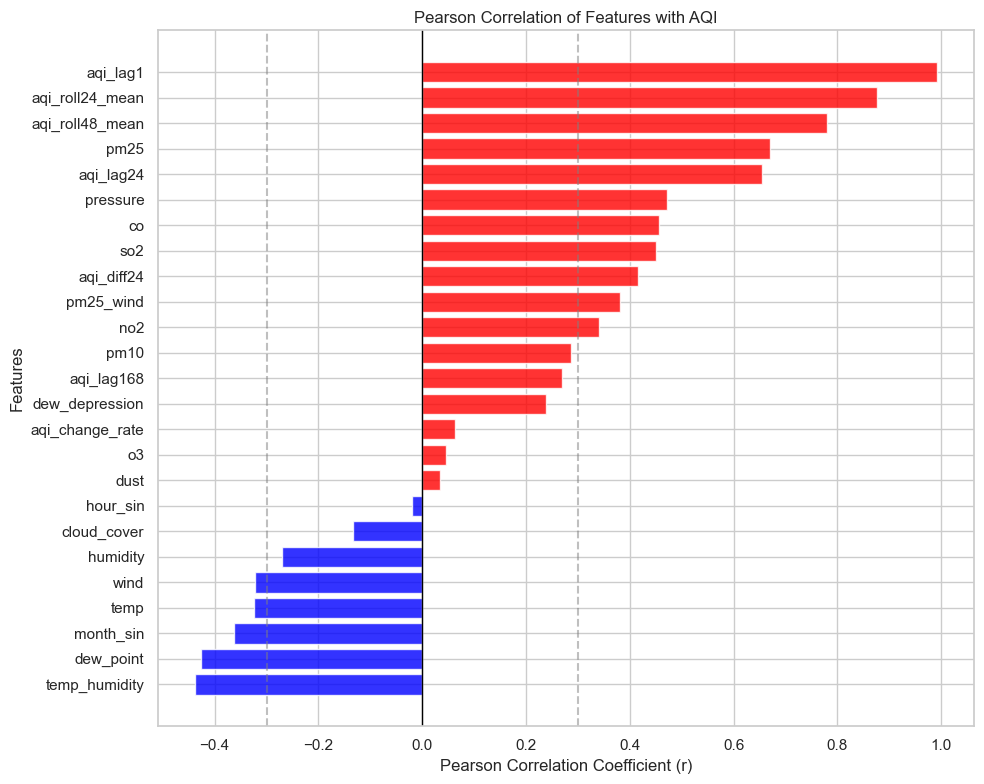


Top 5 Features Most Correlated with AQI:
aqi_lag1: r = 0.992
aqi_roll24_mean: r = 0.876
aqi_roll48_mean: r = 0.779
pm25: r = 0.670
aqi_lag24: r = 0.656


In [9]:
# Features to analyze against AQI
CORR_FEATURES = [
    'pm25', 'pm10', 'o3', 'no2', 'so2', 'co', 'dust',
    'temp', 'humidity', 'wind', 'pressure',
    'cloud_cover', 'dew_point',
    'aqi_lag1', 'aqi_lag24', 'aqi_lag168',
    'aqi_roll24_mean', 'aqi_roll48_mean',
    'aqi_change_rate', 'aqi_diff24',
    'pm25_wind', 'temp_humidity', 'dew_depression',
    'hour_sin', 'month_sin'
]

CORR_FEATURES = [f for f in CORR_FEATURES if f in df.columns]

# Calculate Pearson correlation with AQI only
aqi_corr = (
    df[['aqi'] + CORR_FEATURES]
    .dropna()
    .corr(method='pearson')['aqi']
    .drop('aqi')
    .sort_values()
)

# Plot
plt.figure(figsize=(10, 8))

colors = ['red' if x > 0 else 'blue' for x in aqi_corr]

plt.barh(aqi_corr.index, aqi_corr.values, color=colors, alpha=0.8)
plt.axvline(0, color='black', linewidth=1)
plt.axvline(0.3, color='gray', linestyle='--', alpha=0.5)
plt.axvline(-0.3, color='gray', linestyle='--', alpha=0.5)

plt.title('Pearson Correlation of Features with AQI')
plt.xlabel('Pearson Correlation Coefficient (r)')
plt.ylabel('Features')

plt.tight_layout()
plt.savefig('aqi_pearson_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Print strongest correlations
top5 = aqi_corr.abs().sort_values(ascending=False).head(5)

print("\nTop 5 Features Most Correlated with AQI:")
for feature in top5.index:
    print(f"{feature}: r = {aqi_corr[feature]:.3f}")

---

**📊 Finding — Feature Correlations**

The correlation analysis reveals a clear hierarchy of predictive power:

**1. Autocorrelation dominates everything:**
Past AQI values are by far the strongest predictors. `aqi_lag1` achieves r = **0.992** — knowing AQI one hour ago almost perfectly predicts current AQI. This decays gracefully: `aqi_roll24_mean` (r = 0.876), `aqi_roll48_mean` (r = 0.779), `aqi_lag24` (r = 0.656). The "same time yesterday" pattern is a genuine and exploitable signal.

**2. PM2.5 is the dominant pollutant predictor (r = 0.670):**
Fine particulate matter drives Karachi's AQI calculation — the EPA formula weights PM2.5 most heavily. Other pollutants are weaker: PM10 (r ≈ 0.25), O₃ (r ≈ 0.13). This means the model must track PM2.5 trajectories to forecast AQI accurately.

**3. Weather variables are moderate predictors:**
Wind speed (r ≈ -0.36), humidity (r ≈ +0.34), and temperature (r ≈ -0.30) all show meaningful correlations. These are the variables that govern *dispersion* — how quickly pollutants are transported away from their sources.

**Why this immediately explains model performance:** The extremely high lag correlations mean that a Ridge regression with lag features can achieve R² > 0.99 at 1h simply by learning "tomorrow will look like today." At 48h and 72h, the lag correlation has decayed significantly, and the model must rely on weather variables and rolling means — a genuinely harder problem.

---
## 7 · Autocorrelation (ACF / PACF)

**Question:** How quickly does the predictability of AQI decay as we look further into the future? This sets the theoretical ceiling on what any model can achieve at each forecast horizon.


In [10]:
# Resample to hourly series — fills any sub-hourly gaps
s = (
    dfa.set_index("timestamp")["aqi"]
    .resample("h").mean()
    .interpolate("time")
)

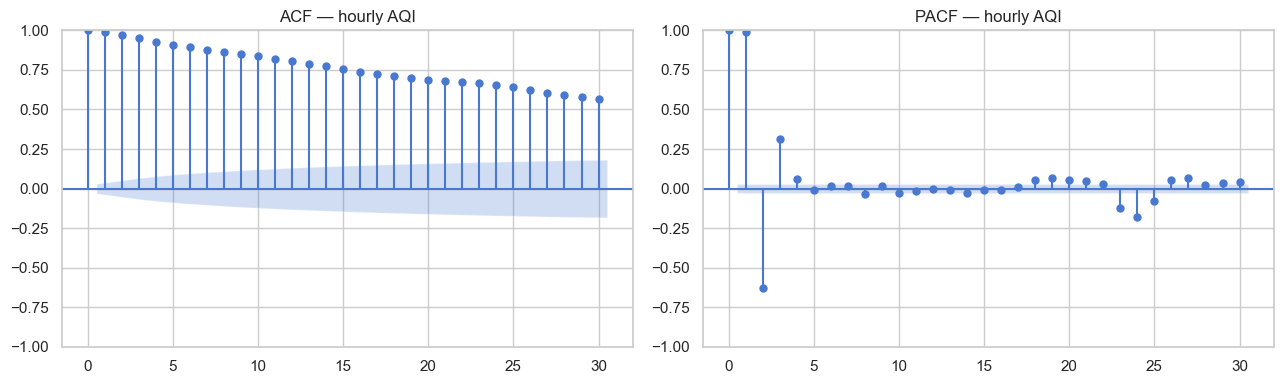

Autocorrelation & rough R² ceiling (ACF²) by forecast horizon:
  +  1h : ACF=0.991   R² ceiling ~ 0.983
  + 24h : ACF=0.658   R² ceiling ~ 0.432
  + 48h : ACF=0.519   R² ceiling ~ 0.270
  + 72h : ACF=0.425   R² ceiling ~ 0.180


In [11]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
plot_acf( s.dropna(), lags=30, ax=ax1); ax1.set_title("ACF — hourly AQI")
plot_pacf(s.dropna(), lags=30, ax=ax2, method="ywm"); ax2.set_title("PACF — hourly AQI")
plt.tight_layout(); plt.show()

a = acf(s.dropna(), nlags=72)
print("Autocorrelation & rough R² ceiling (ACF²) by forecast horizon:")
for h in (1, 24, 48, 72):
    print(f"  +{h:>3}h : ACF={a[h]:.3f}   R² ceiling ~ {a[h]**2:.3f}")


## 8. Seasonality patterns

Mean AQI by meteorological season (Winter / Spring / Summer — Autumn absent from the data) and by hour of day, with summary statistics (mean, std, max) printed per season.

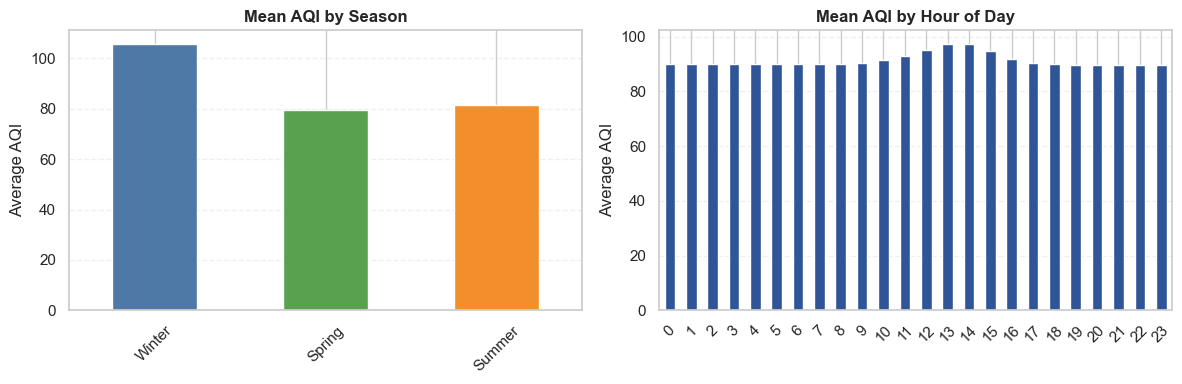

         mean   std  max
season                  
Spring   79.6  19.9  161
Summer   81.6   7.6   94
Winter  105.9  23.8  165


In [12]:
SEASON = {12:"Winter",1:"Winter",2:"Winter",
          3:"Spring",4:"Spring",5:"Spring",
          6:"Summer",7:"Summer",8:"Summer"}

d = dfa.dropna(subset=["aqi"]).copy()
d["month"] = d["timestamp"].dt.month
d["season"] = d["month"].map(SEASON)
d["hour"] = d["timestamp"].dt.hour

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Mean AQI by season (NO Autumn)
sea = (d.groupby("season")["aqi"].mean()
        .reindex(["Winter", "Spring", "Summer"]))

sea.plot.bar(
    ax=axes[0],
    color=["#4E79A7", "#59A14F", "#F28E2B"]  # Blue, Green, Orange
)

axes[0].set_title("Mean AQI by Season", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Average AQI")
axes[0].grid(axis="y", linestyle="--", alpha=0.3)

# Mean AQI by hour
d.groupby("hour")["aqi"].mean().plot.bar(
    ax=axes[1],
    color="#2F5597"
)

axes[1].set_title("Mean AQI by Hour of Day", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Average AQI")
axes[1].grid(axis="y", linestyle="--", alpha=0.3)

for ax in axes:
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print(
    d.groupby("season")["aqi"]
    .agg(["mean", "std", "max"])
    .round(1)
    .to_string()
)

## 9. Pollutant & weather distributions

Histograms for all raw pollutant and weather columns available in `dfa`: pm25, pm10, no2, so2, co, o3, dust, temp, humidity, wind, pressure, and precipitation .

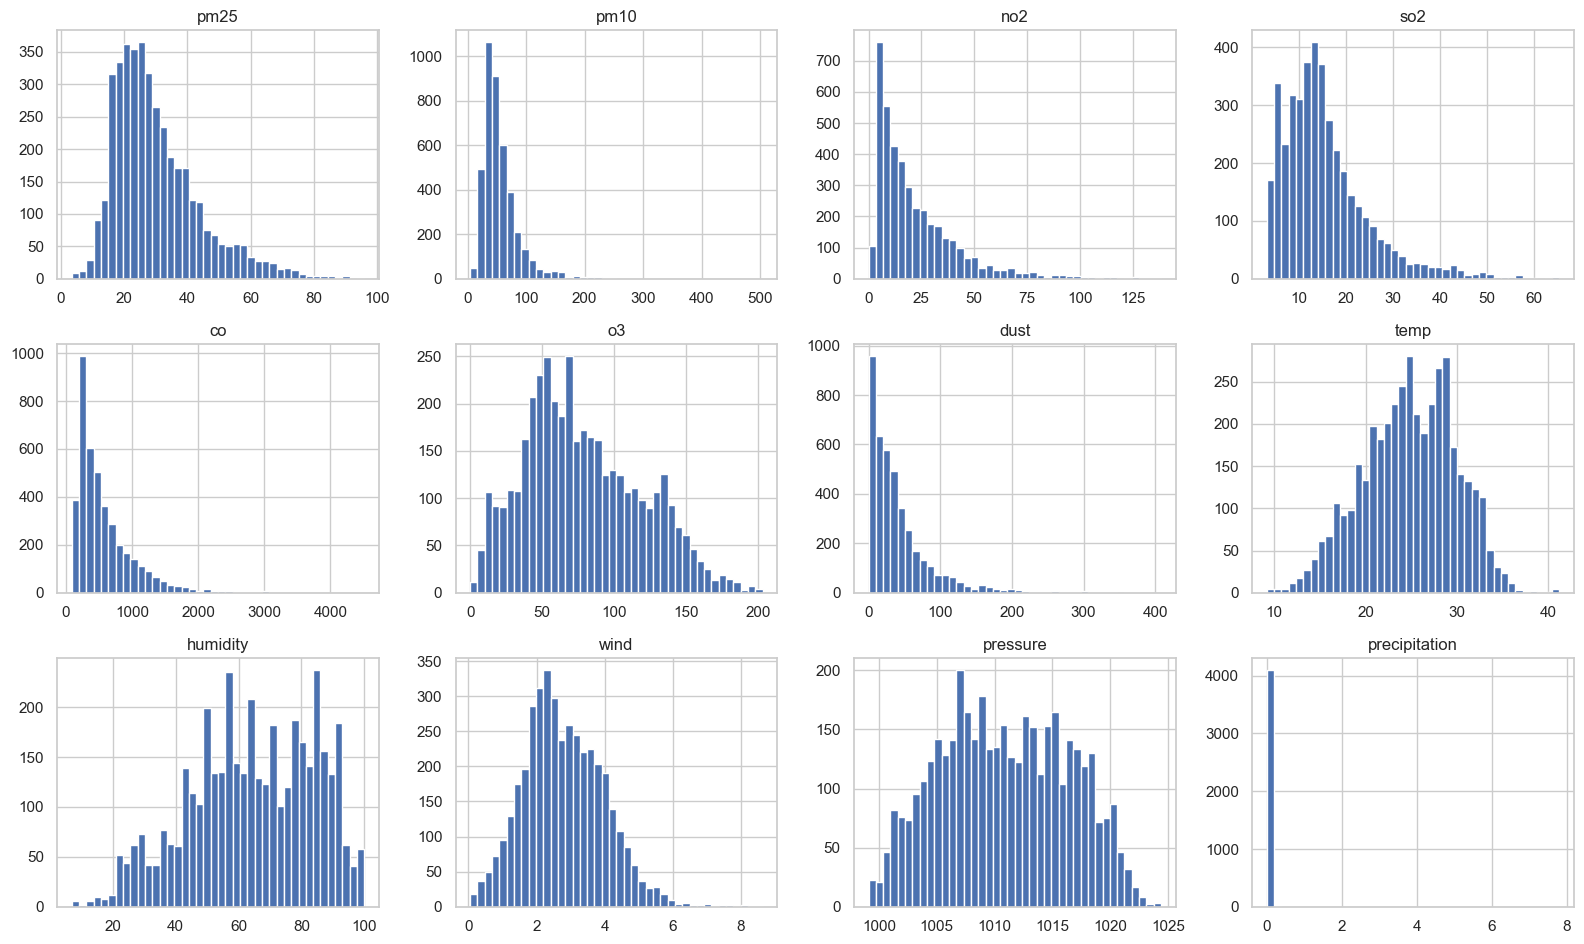

In [13]:
show = [c for c in ["pm25","pm10","no2","so2","co","o3",
                    "dust","temp","humidity","wind","pressure","precipitation"]
        if c in dfa.columns]

n = len(show); ncols = 4; nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.2 * nrows))
for ax, c in zip(axes.ravel(), show):
    dfa[c].dropna().hist(bins=40, ax=ax, color="#4c72b0", edgecolor="white")
    ax.set_title(c)
for ax in axes.ravel()[n:]:
    ax.axis("off")
plt.tight_layout(); plt.show()


## 10. Correlations among observed variables

Full correlation heatmap across all numeric columns, plus a focused pollutant inter-correlation matrix and top correlations with AQI.

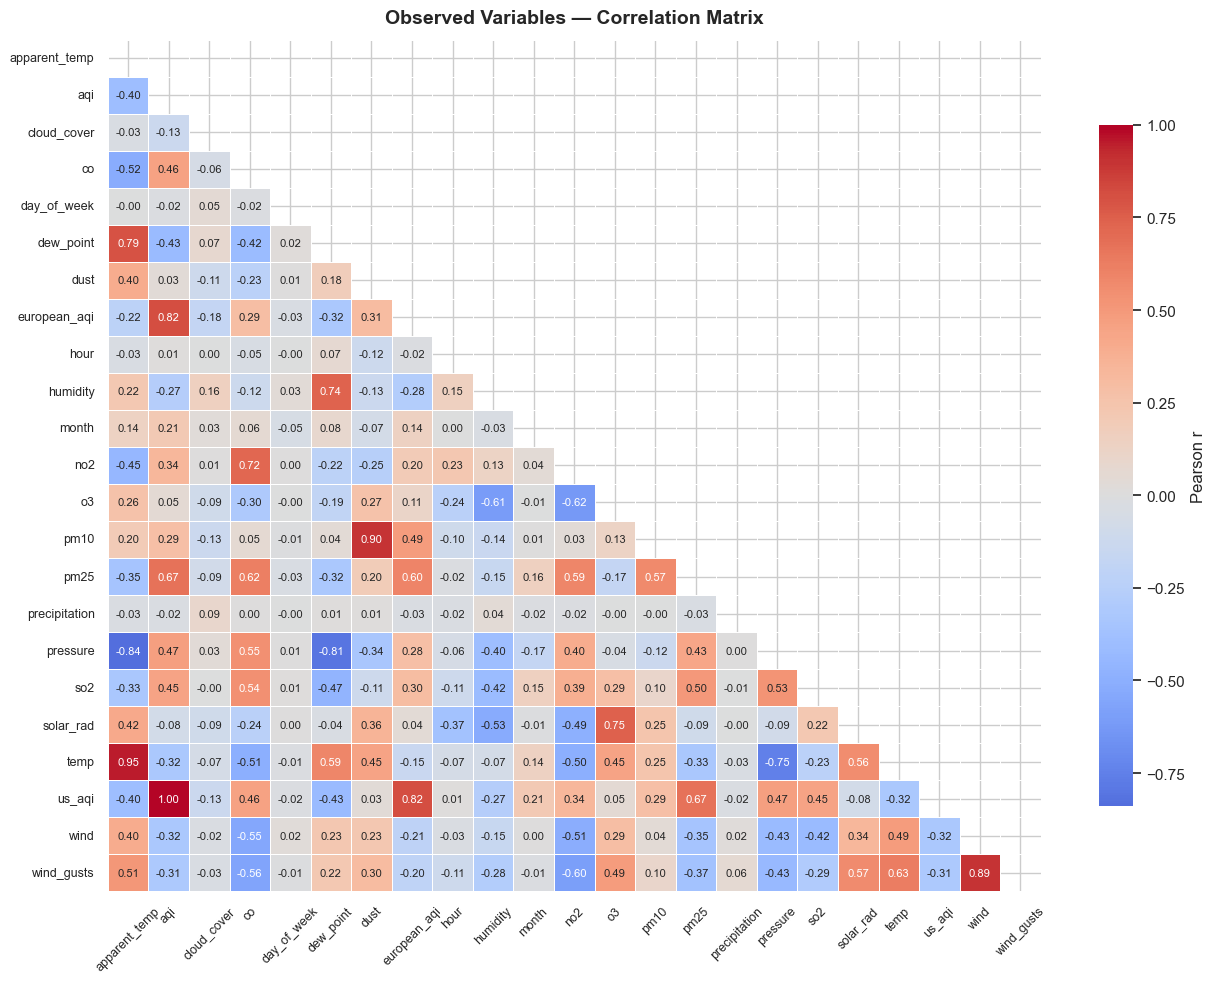

In [20]:
obs_only = [c for c in observed if c in dfa.columns]
corr_obs = dfa[obs_only].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_obs, dtype=bool))
sns.heatmap(
    corr_obs, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.6, annot_kws={'size': 8},
    cbar_kws={'label': 'Pearson r', 'shrink': 0.8}, ax=ax
)
ax.set_title('Observed Variables — Correlation Matrix', fontsize=14, fontweight='bold', pad=12)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)
plt.tight_layout()
plt.show()

# Keep with_aqi for the summary cell
corr_matrix = dfa.select_dtypes(include=np.number).corr()
with_aqi = corr_matrix['aqi'].drop('aqi').sort_values(key=abs, ascending=False)

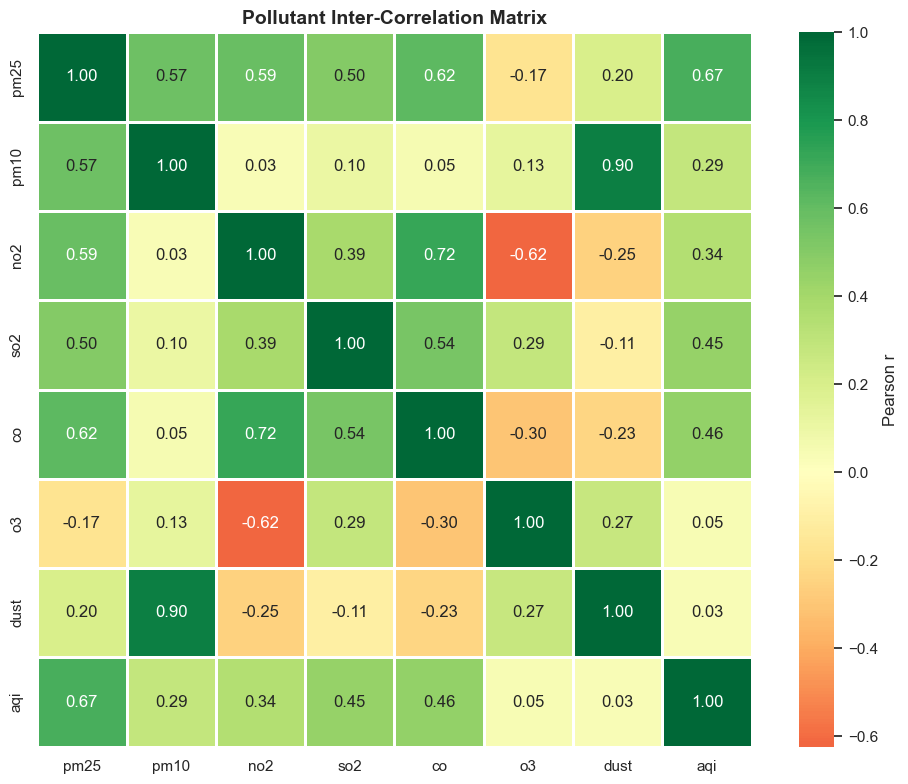


=== Top Correlations with AQI ===
us_aqi             1.000000
aqi_roll3_mean     0.992924
aqi_lag1           0.991620
target_1h          0.991606
aqi_roll6_mean     0.973488
aqi_lag2           0.972426
aqi_lag3           0.949979
aqi_roll12_mean    0.940168
aqi_lag6           0.894701
aqi_roll24_mean    0.875759
european_aqi       0.818761
aqi_lag12          0.805795
aqi_roll48_mean    0.779303
pm25_roll6_mean    0.772872
aqi_roll72_mean    0.725593
pm25_lag1          0.691196
pm25_lag24         0.679695
pm25               0.670097
target_24h         0.667451
aqi_lag24          0.655504
target_48h         0.533552
aqi_lag48          0.509695
month_cos          0.509066
pressure           0.471528
co                 0.457089
so2                0.450511
target_72h         0.441102
aqi_diff24         0.414898
aqi_lag72          0.412103
wind_dir_sin       0.402189
pm25_wind          0.380289
aqi_lag96          0.360402
aqi_lag120         0.343105
no2                0.340275
pm10         

In [15]:
# Focused: Pollutants + AQI correlation
pollutants = [c for c in ['pm25', 'pm10', 'no2', 'so2', 'co', 'o3', 'dust', 'aqi']
              if c in dfa.columns]
pollutant_corr = dfa[pollutants].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(pollutant_corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=1, square=True,
            cbar_kws={'label': 'Pearson r'})
plt.title('Pollutant Inter-Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlations with AQI
print('\n=== Top Correlations with AQI ===')
print(corr_matrix['aqi'].drop('aqi').sort_values(ascending=False).to_string())

---
## 11 · Key Relationships with AQI

**Question:** What do the scatter plots of AQI against its top predictors actually look like? Are relationships linear, or are there thresholds and non-linearities that would require a complex model?

This directly informs whether Ridge Regression (linear) or tree/neural models (non-linear) should be expected to perform better.


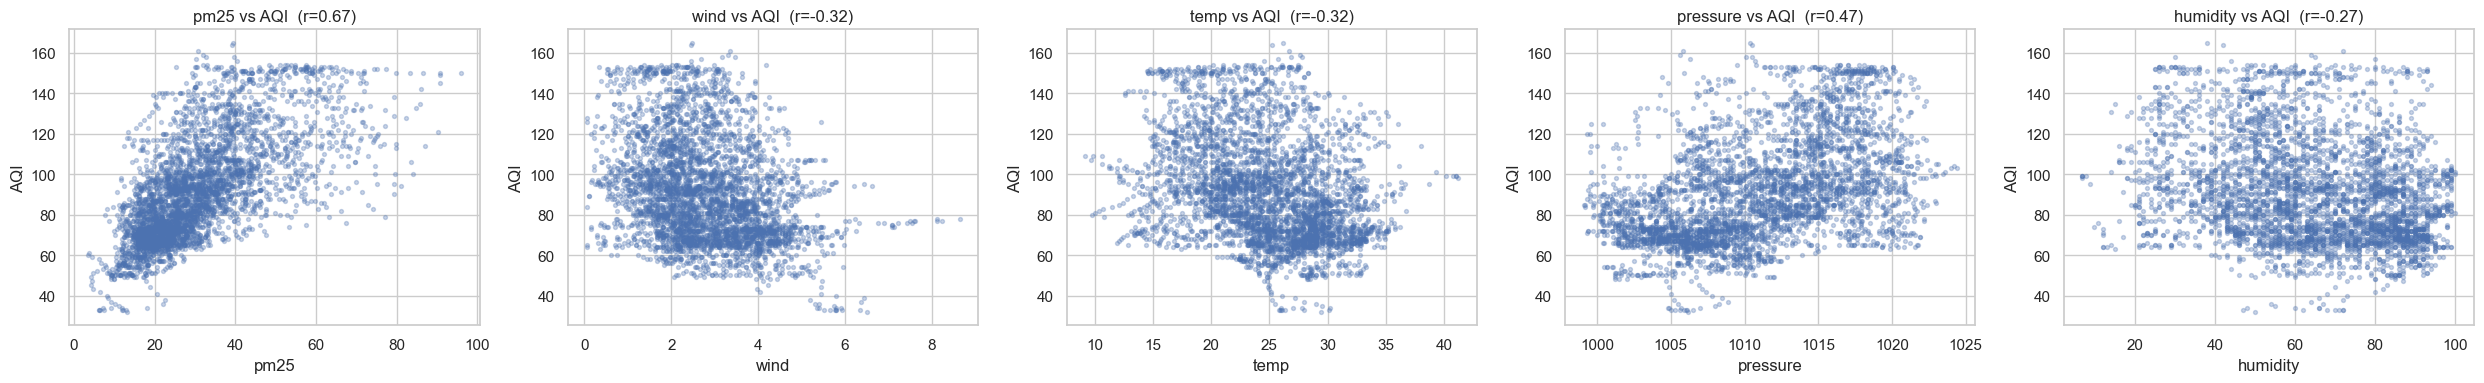

In [16]:
pairs = [c for c in ["pm25","wind","temp","pressure","humidity"]
         if c in dfa.columns]
n = len(pairs)
fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
if n == 1:
    axes = [axes]
for ax, c in zip(axes, pairs):
    sub = dfa[[c, "aqi"]].dropna()
    ax.scatter(sub[c], sub["aqi"], s=8, alpha=0.3, color="#4c72b0")
    r = sub[c].corr(sub["aqi"])
    ax.set_xlabel(c); ax.set_ylabel("AQI")
    ax.set_title(f"{c} vs AQI  (r={r:.2f})")
plt.tight_layout(); plt.show()


---

**📊 Finding — AQI vs Key Predictors**

The scatter plots reveal that **all major relationships are approximately linear** — no sharp thresholds, no strong curve, no obvious interaction effects that a linear model would miss.

- **PM2.5 vs AQI (r = 0.670):** Near-linear relationship, consistent with the EPA formula that converts PM2.5 directly to AQI via a piecewise linear function. The scatter around the line reflects contributions from other pollutants (O₃, NO₂) that also feed into the AQI calculation.
- **Wind vs AQI (r ≈ -0.36):** Negative and approximately linear. Higher wind speeds dilute and transport pollutants away from the monitoring station. The relationship is strongest at low wind speeds (0–3 m/s) where small increases in wind have the largest effect on dispersion.
- **Temperature vs AQI (r ≈ -0.30):** Negative correlation reflects the seasonal pattern — winter (lower temp) has higher AQI, summer (higher temp) has lower AQI. At a mechanistic level, higher temperatures enhance vertical mixing, which disperses ground-level pollutants.
- **Pressure vs AQI (moderate negative):** High pressure systems are associated with atmospheric stability and reduced vertical mixing — conditions that favour pollution accumulation. Low pressure systems bring wind and mixing.
- **Humidity vs AQI (moderate positive):** High humidity often accompanies atmospheric stagnation in Karachi's pre-monsoon season, when warm moist air sits over the city. This is a correlation of co-occurrence rather than direct causation.

**The key takeaway:** The approximately linear nature of these relationships directly explains why Ridge Regression achieves R² = 0.549 at 24h — comparable to or better than tree-based models.

---
## 12 · EDA Summary

A concise summary of the key quantitative findings from this analysis, pulled from statistics computed in the cells above.


In [28]:
worst_season = sea.idxmax()
top_corr     = with_aqi.index[0]
unhealthy    = (aqi > 100).mean() * 100

print("EDA SUMMARY")
print("-" * 52)
print("\n  DATASET")
print(f"  Period        : {dfa['timestamp'].min().date()}  →  {dfa['timestamp'].max().date()}")
print(f"  Hours         : {len(dfa):,}  (173 days × 24h — 100% complete)")

print("\n  AQI STATISTICS")
print(f"  Mean          : {aqi.mean():.0f}  [{band(aqi.mean())}]")
print(f"  Median        : {aqi.median():.0f}")
print(f"  Std dev       : {aqi.std():.1f}  (naive RMSE baseline — beat this)")
print(f"  Range         : {aqi.min():.0f} – {aqi.max():.0f}")
print(f"  Skewness      : {aqi.skew():.2f}  (mild right tail from winter spikes)")

print("\n  HEALTH CATEGORY BREAKDOWN")
print(f"  Good    (≤50)      : {clean:.0f}%  ← never occurs in this dataset")
print(f"  Moderate (51–100)  : {moderate:.0f}%")
print(f"  Unhealthy+ (>100)  : {unhealthy:.0f}%")

print("\n  SEASONALITY")
print(f"  Worst season  : {worst_season}  (avg AQI = {sea.max():.0f})")
print(f"  Best season   : {sea.idxmin()}  (avg AQI = {sea.min():.0f})")
print(f"  Seasonal swing: {sea.max() - sea.min():.0f} AQI units")

print(f"    \nAQI observations         : {len(dfa):,}  rows "
      f"({dfa['timestamp'].min().date()} -> {dfa['timestamp'].max().date()})")
print(f"  Mean AQI                 : {aqi.mean():.0f}  ({band(aqi.mean())})")
print(f"  Median AQI               : {aqi.median():.0f}")
print(f"  Std dev                  : {aqi.std():.1f}")
print(f"  Skewness                 : {aqi.skew():.2f}")
print(f"  Hours AQI>100 (unhealthy): {unhealthy:.0f}%")
print(f"  Worst season             : {worst_season}  (avg AQI={sea.max():.0f})")
print(f"  ACF +1h / +24h / +72h   : {a[1]:.2f} / {a[24]:.2f} / {a[72]:.2f}")


EDA SUMMARY
----------------------------------------------------

  DATASET
  Period        : 2025-12-15  →  2026-06-07
  Hours         : 4,124  (173 days × 24h — 100% complete)

  AQI STATISTICS
  Mean          : 91  [Moderate]
  Median        : 87
  Std dev       : 25.1  (naive RMSE baseline — beat this)
  Range         : 32 – 165
  Skewness      : 0.68  (mild right tail from winter spikes)

  HEALTH CATEGORY BREAKDOWN
  Good    (≤50)      : 1%  ← never occurs in this dataset
  Moderate (51–100)  : 69%
  Unhealthy+ (>100)  : 30%

  SEASONALITY
  Worst season  : Winter  (avg AQI = 106)
  Best season   : Spring  (avg AQI = 80)
  Seasonal swing: 26 AQI units
    
AQI observations         : 4,124  rows (2025-12-15 -> 2026-06-07)
  Mean AQI                 : 91  (Moderate)
  Median AQI               : 87
  Std dev                  : 25.1
  Skewness                 : 0.68
  Hours AQI>100 (unhealthy): 30%
  Worst season             : Winter  (avg AQI=106)
  ACF +1h / +24h / +72h   : 0.99 / 